In [21]:
!pip install imbalanced-learn wordcloud xgboost --quiet

 Import All Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

Load the Dataset

In [23]:
df = pd.read_csv("fake_job_postings.csv", engine='python', on_bad_lines='skip')

Exploratory Data Analysis

In [24]:
print(f'Total rows (job postings): {df.shape[0]:,}')
print(f'Total columns (features):  {df.shape[1]}')

Total rows (job postings): 17,880
Total columns (features):  18


In [25]:
print('COLUMNS IN DATASET:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i:2}. {col}')

COLUMNS IN DATASET:
   1. job_id
   2. title
   3. location
   4. department
   5. salary_range
   6. company_profile
   7. description
   8. requirements
   9. benefits
  10. telecommuting
  11. has_company_logo
  12. has_questions
  13. employment_type
  14. required_experience
  15. required_education
  16. industry
  17. function
  18. fraudulent


In [26]:
df.head(3)

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0


In [27]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

In [28]:
print('TARGET COLUMN (fraudulent):')
print(df['fraudulent'].value_counts())
print()

fake_count = df['fraudulent'].sum()           # count of 1s (fake)
real_count = len(df) - fake_count             # count of 0s (real)
fake_percent = (fake_count / len(df)) * 100   # percentage

print(f'Real jobs : {real_count:,} ({100-fake_percent:.1f}%)')
print(f'Fake jobs : {fake_count:,} ({fake_percent:.1f}%)')
print()
print(f'Only {fake_percent:.1f}% of jobs are fake')
print('This is called CLASS IMBALANCE')

TARGET COLUMN (fraudulent):
fraudulent
0    17014
1      866
Name: count, dtype: int64

Real jobs : 17,014 (95.2%)
Fake jobs : 866 (4.8%)

Only 4.8% of jobs are fake
This is called CLASS IMBALANCE


Chart 1: Class Distribution (Fake vs Real)

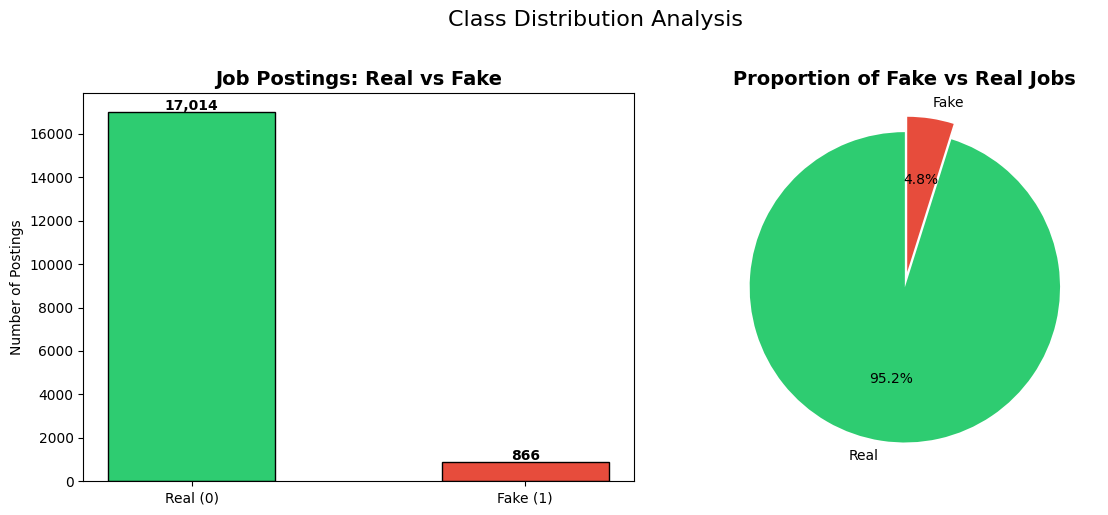

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df['fraudulent'].value_counts()
colors = ['#2ecc71', '#e74c3c']  # green for real, red for fake
axes[0].bar(['Real (0)', 'Fake (1)'], counts.values, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Job Postings: Real vs Fake', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Postings')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    counts.values,
    labels=['Real', 'Fake'],
    colors=colors,
    autopct='%1.1f%%',  # show percentage
    startangle=90,
    explode=(0, 0.1)   # explode the Fake slice slightly
)
axes[1].set_title('Proportion of Fake vs Real Jobs', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution Analysis', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Observation: It have severe class imbalance.Only 4.8% are fake jobs.
If we just predict every job as real, we get 95.2% accuracy but we would miss all fake jobs.This is why accuracy alone is a bad metric here. We need F1-Score and Recall.

Chart 2: Missing Values Heatmap

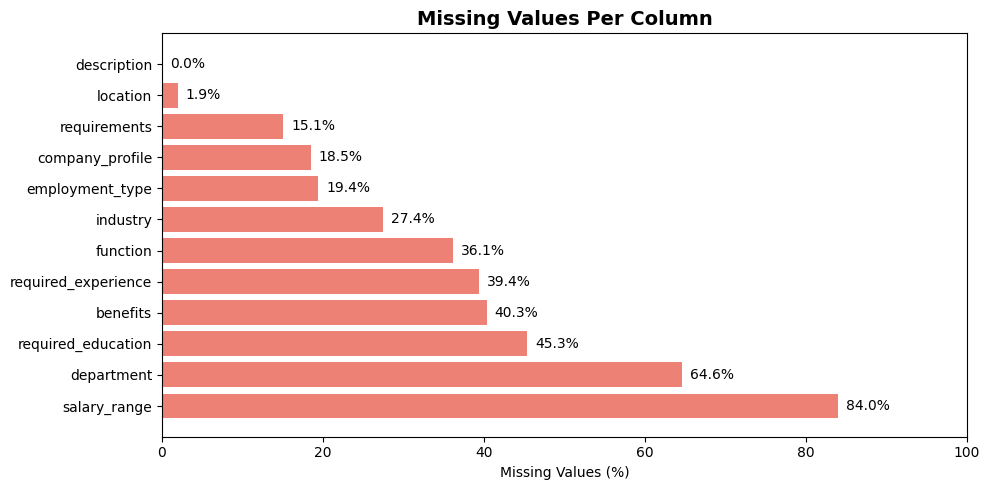

In [30]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing_percent[missing_percent > 0].reset_index()
missing_df.columns = ['Column', 'Missing %']

plt.figure(figsize=(10, 5))
bars = plt.barh(missing_df['Column'], missing_df['Missing %'], color='#e74c3c', alpha=0.7)
plt.xlabel('Missing Values (%)')
plt.title('Missing Values Per Column', fontsize=14, fontweight='bold')
plt.xlim(0, 100)

# Add percentage labels
for bar, val in zip(bars, missing_df['Missing %']):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center')

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

 Chart 3: Top 10 Industries with Fake Jobs

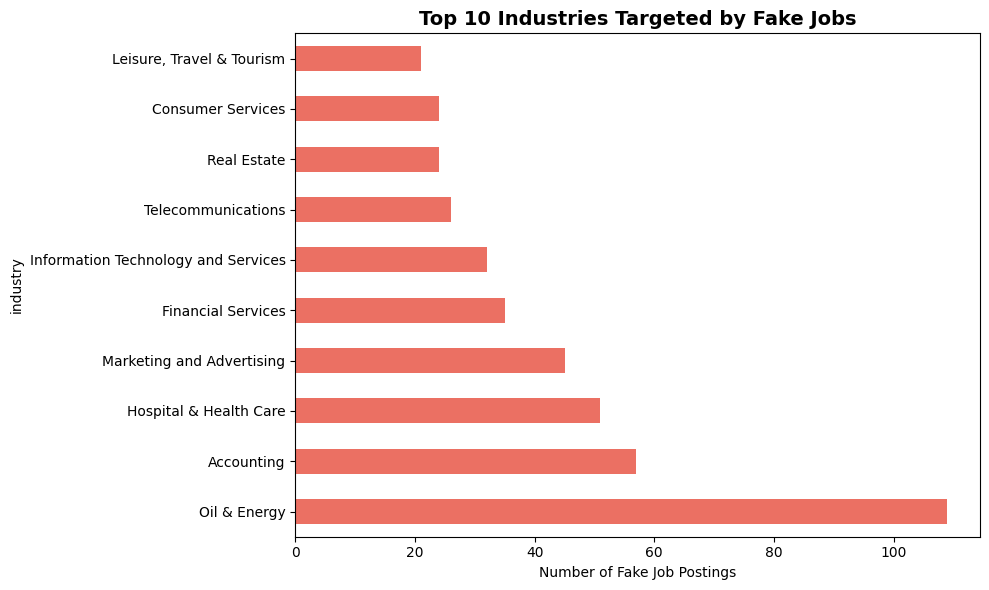

In [31]:
fake_jobs = df[df['fraudulent'] == 1]
real_jobs = df[df['fraudulent'] == 0]

fake_industry = fake_jobs['industry'].dropna().value_counts().head(10)

plt.figure(figsize=(10, 6))
fake_industry.plot(kind='barh', color='#e74c3c', alpha=0.8)
plt.xlabel('Number of Fake Job Postings')
plt.title('Top 10 Industries Targeted by Fake Jobs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_industries.png', dpi=150, bbox_inches='tight')
plt.show()

 Chart 4: Word Clouds for Fake vs Real Jobs

In [32]:
fake_text = ' '.join(
    (fake_jobs['title'].fillna('') + ' ' + fake_jobs['description'].fillna('')).tolist()
)
real_text = ' '.join(
    (real_jobs['title'].fillna('') + ' ' + real_jobs['description'].fillna('')).tolist()
)

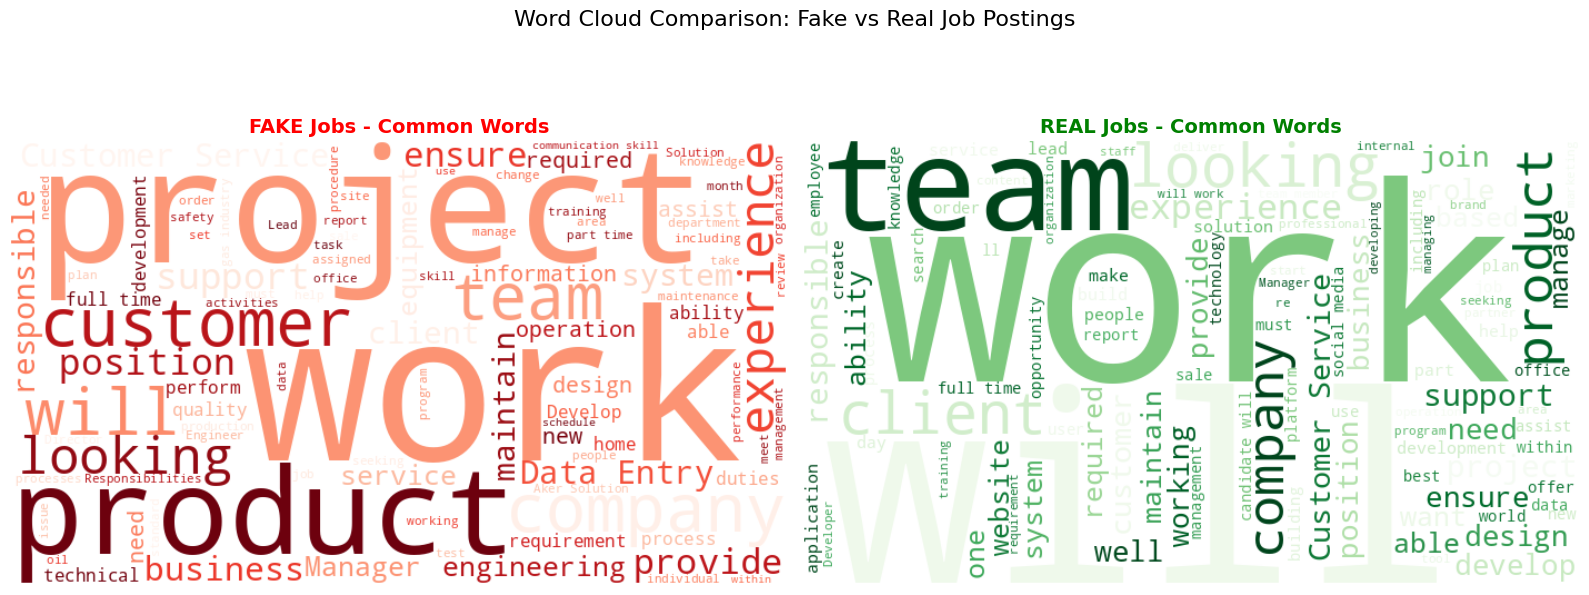

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Fake jobs word cloud
wc_fake = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Reds', # red shades for fake
    max_words=100
).generate(fake_text)

axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('FAKE Jobs - Common Words', fontsize=14, fontweight='bold', color='red')

# Real jobs word cloud
wc_real = WordCloud(
    width=700, height=400,
    background_color='white',
    colormap='Greens', # green shades for real
    max_words=100
).generate(real_text)

axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('REAL Jobs - Common Words', fontsize=14, fontweight='bold', color='green')

plt.suptitle('Word Cloud Comparison: Fake vs Real Job Postings', fontsize=16)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

Observation: fake and real jobs use similar vocabulary, which proved that simple keyword-based detection is insufficient and justified the use of TF-IDF with machine learning models.

Data Preprocessing and Feature Engineering

Combine text columns into one

In [34]:
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']

In [35]:
df['combined_text'] = (
    df['title'].fillna('') + ' ' +
    df['company_profile'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['requirements'].fillna('') + ' ' +
    df['benefits'].fillna('')
)

In [36]:
df['combined_text'].iloc[0][:200]

"Marketing Intern We're Food52, and we've created a groundbreaking and award-winning cooking site. We support, connect, and celebrate home cooks, and give them everything they need in one place.We have"

 Text Cleaning

In [37]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [38]:
df['clean_text'] = df['combined_text'].apply(clean_text)

In [39]:
df['clean_text'].iloc[0][:301]

'marketing intern we re food52 and we ve created a groundbreaking and award winning cooking site we support connect and celebrate home cooks and give them everything they need in one place we have a top editorial business and engineering team we re focused on using technology to find new and better wa'

 Add Extra Features

Feature 1: Length of the job description

In [40]:
df['text_length'] = df['clean_text'].apply(len) #Fake jobs often have very short descriptions

Feature 2: Word count

In [41]:
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

Feature 3: Does it have a company logo? (binary: 0 or 1)

In [42]:
df['has_logo'] = df['has_company_logo'].fillna(0).astype(int) # Fake jobs rarely have logos

 Feature 4: Does it allow telecommuting? (binary)

In [43]:
df['telecommute'] = df['telecommuting'].fillna(0).astype(int)


 Feature 5: Has company questions (binary)

In [44]:
df['has_questions'] = df['has_questions'].fillna(0).astype(int)

In [45]:
extra_features = ['text_length', 'word_count', 'has_logo', 'telecommute', 'has_questions']

In [46]:
df[extra_features + ['fraudulent']].describe().round(2)

,text_length,word_count,has_logo,telecommute,has_questions,fraudulent
count,17880.00,17880.00,17880.0,17880.00,17880.00,17880.00
mean,2595.50,392.33,0.8,0.04,0.49,0.05
std,1421.13,218.93,0.4,0.20,0.50,0.21
min,14.00,2.00,0.0,0.00,0.00,0.00
25%,1555.00,239.00,1.0,0.00,0.00,0.00
50%,2457.00,366.00,1.0,0.00,0.00,0.00
75%,3387.25,514.00,1.0,0.00,1.00,0.00
max,14599.00,2200.00,1.0,1.00,1.00,1.00


 Visualize: Do extra features differ for fake vs real?

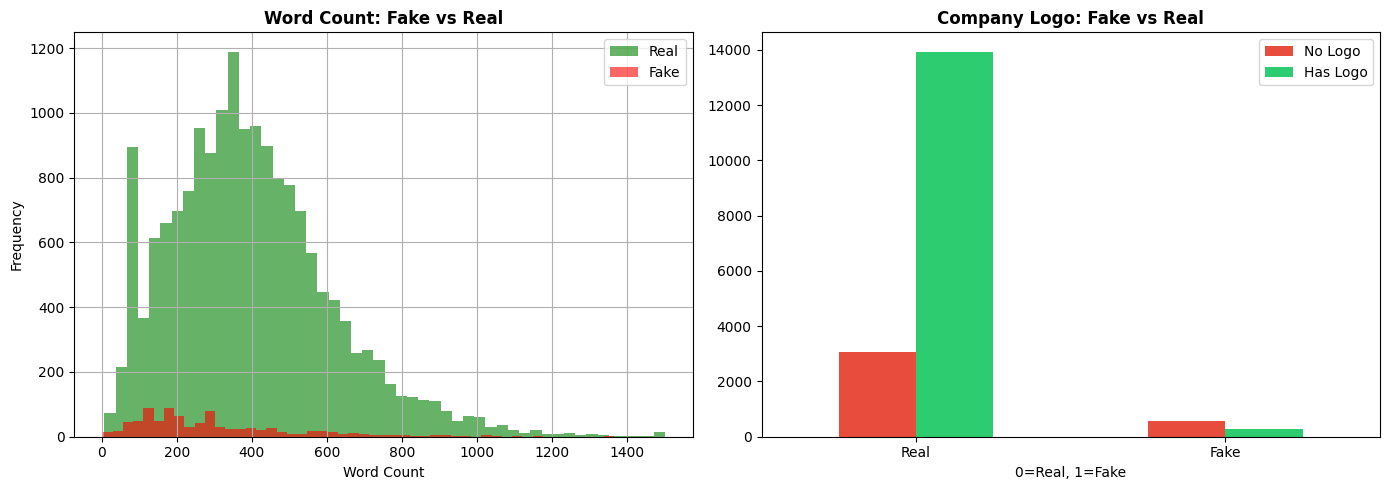

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length distribution
df[df['fraudulent']==0]['word_count'].clip(0, 1500).hist(
    bins=50, ax=axes[0], alpha=0.6, color='green', label='Real'
)
df[df['fraudulent']==1]['word_count'].clip(0, 1500).hist(
    bins=50, ax=axes[0], alpha=0.6, color='red', label='Fake'
)
axes[0].set_title('Word Count: Fake vs Real', fontweight='bold')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Logo presence
logo_data = df.groupby(['fraudulent', 'has_logo']).size().unstack()
logo_data.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'])
axes[1].set_title('Company Logo: Fake vs Real', fontweight='bold')
axes[1].set_xlabel('0=Real, 1=Fake')
axes[1].set_xticklabels(['Real', 'Fake'], rotation=0)
axes[1].legend(['No Logo', 'Has Logo'])

plt.tight_layout()
plt.savefig('feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

Observation: Fake jobs tend to have fewer words and less often have company logos.

Prepare Data for Machine Learning

Define X and y

In [48]:
y = df['fraudulent'].values
X_text = df['clean_text'].values
X_extra = df[['text_length', 'word_count', 'has_logo', 'telecommute', 'has_questions']].values

Train-Test Split

In [49]:
X_text_train, X_text_test, X_extra_train, X_extra_test, y_train, y_test = train_test_split(
    X_text, X_extra, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

TF-IDF Vectorization

In [50]:
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [51]:
X_tfidf_train = tfidf.fit_transform(X_text_train)

In [52]:
X_tfidf_test = tfidf.transform(X_text_test)

In [53]:
print(f'Training matrix shape: {X_tfidf_train.shape}')
print(f'  {X_tfidf_train.shape[0]} job postings × {X_tfidf_train.shape[1]} words')
print(f'Test matrix shape:     {X_tfidf_test.shape}')

Training matrix shape: (14304, 20000)
  14304 job postings × 20000 words
Test matrix shape:     (3576, 20000)


Combine TF-IDF features + Extra features

In [54]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix
X_train_final = hstack([X_tfidf_train, csr_matrix(X_extra_train)])
X_test_final  = hstack([X_tfidf_test,  csr_matrix(X_extra_test)])

In [55]:
print(f'Final training matrix: {X_train_final.shape}')
print(f'  20,000 TF-IDF features + 5 engineered features = {X_train_final.shape[1]} total features')
print(f'Final test matrix: {X_test_final.shape}')

Final training matrix: (14304, 20005)
  10,000 TF-IDF features + 5 engineered features = 20005 total features
Final test matrix: (3576, 20005)


Train Three Models and Compare

In [56]:
def train_evaluate_model(model, model_name, X_train, y_train, X_test, y_test):
    print(f'Training {model_name}...', end=' ')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results = {
        'model': model,
        'name': model_name,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, y_proba),
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }

    print(f'Done! F1={results["f1"]:.3f}, ROC-AUC={results["roc_auc"]:.3f}')
    return results

Model 1: Logistic Regression



In [57]:
# Logistic Regression — baseline model
# class_weight='balanced' handles imbalance properly for text data
lr_model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    random_state=42
)
lr_results = train_evaluate_model(
    lr_model, 'Logistic Regression',
    X_train_final, y_train,
    X_test_final, y_test
)


Training Logistic Regression... Done! F1=0.706, ROC-AUC=0.993


Model 2: Random Forest

In [58]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_results = train_evaluate_model(
    rf_model, 'Random Forest',
    X_train_final, y_train,
    X_test_final, y_test
)


Training Random Forest... Done! F1=0.656, ROC-AUC=0.979


Model 3: XGBoost

In [59]:
# XGBoost — Gradient Boosting
# scale_pos_weight = ratio of real/fake jobs
# tells XGBoost to give more importance to fake jobs during training

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f'scale_pos_weight = {scale:.1f}')
print(f'This means fake jobs are weighted {scale:.0f}x more than real jobs')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    eval_metric="logloss",
    verbosity=0
)
xgb_results = train_evaluate_model(
    xgb_model, 'XGBoost',
    X_train_final, y_train,
    X_test_final, y_test
)


scale_pos_weight = 19.6
This means fake jobs are weighted 20x more than real jobs
Training XGBoost... Done! F1=0.836, ROC-AUC=0.989


Compare Models and Select Best

Create comparison table

In [60]:
all_results = [lr_results, rf_results, xgb_results]

comparison_df = pd.DataFrame([
    {
        'Model': r['name'],
        'Accuracy': f"{r['accuracy']:.4f}",
        'Precision': f"{r['precision']:.4f}",
        'Recall': f"{r['recall']:.4f}",
        'F1 Score': f"{r['f1']:.4f}",
        'ROC-AUC': f"{r['roc_auc']:.4f}"
    }
    for r in all_results
])

print('=' * 70)
print('MODEL COMPARISON TABLE')
print('=' * 70)
print(comparison_df.to_string(index=False))
print()
print('KEY: For fraud detection, F1 Score and Recall matter most!')
print('Recall = how many fake jobs we actually catch')

MODEL COMPARISON TABLE
              Model Accuracy Precision Recall F1 Score ROC-AUC
Logistic Regression   0.9628    0.5714 0.9249   0.7064  0.9929
      Random Forest   0.9648    0.6218 0.6936   0.6557  0.9789
            XGBoost   0.9852    0.9000 0.7803   0.8359  0.9887

KEY: For fraud detection, F1 Score and Recall matter most!
Recall = how many fake jobs we actually catch


Visualize Comparison

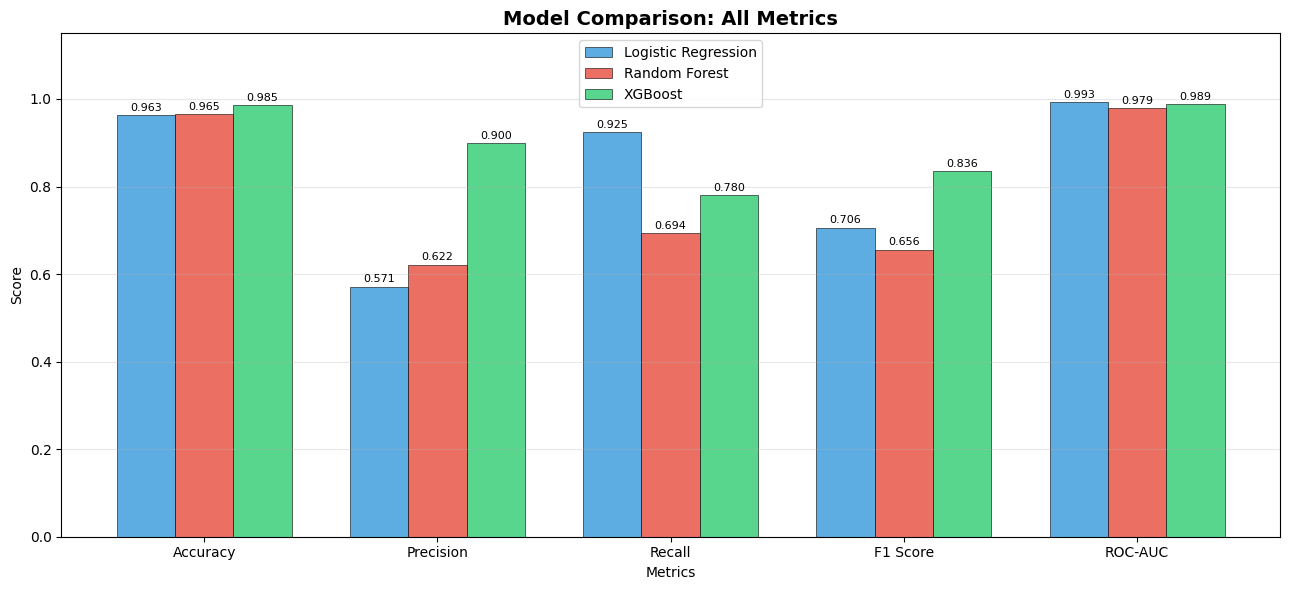

In [61]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
model_names = [r['name'] for r in all_results]
colors_list = ['#3498db', '#e74c3c', '#2ecc71']

x = np.arange(len(metrics))  # x positions for groups
width = 0.25  # width of each bar

fig, ax = plt.subplots(figsize=(13, 6))

for i, (results, color) in enumerate(zip(all_results, colors_list)):
    values = [results[m] for m in metrics]
    bars = ax.bar(x + i*width, values, width, label=results['name'],
                  color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    # Add value labels on top of bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrics')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: All Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

ROC Curve Plot

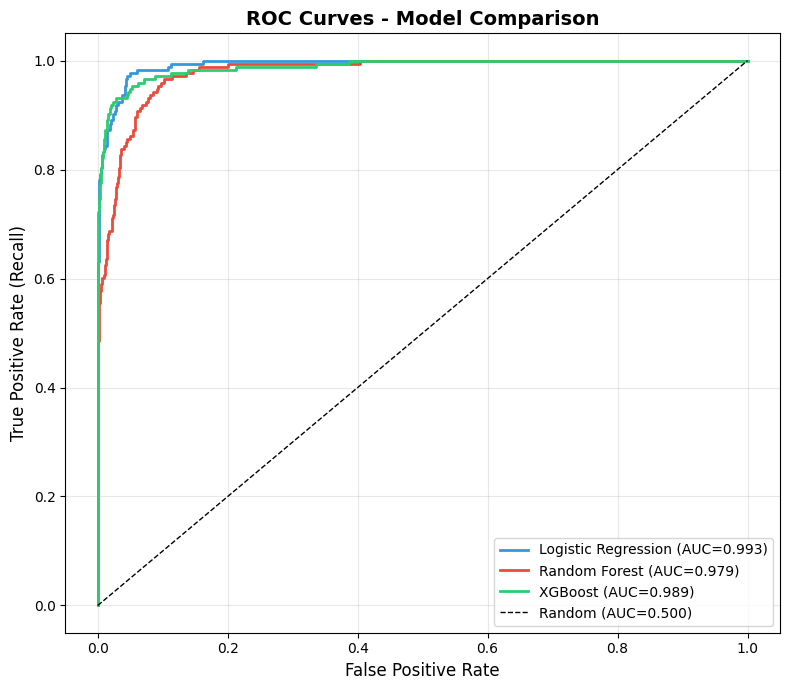

In [62]:
# ROC curve shows trade-off between True Positive Rate and False Positive Rate
# The more the curve bends toward top-left, the better the model
# AUC (Area Under Curve) = single number: 1.0 = perfect, 0.5 = random

plt.figure(figsize=(8, 7))

for results, color in zip(all_results, colors_list):
    fpr, tpr, _ = roc_curve(y_test, results['y_proba'])
    auc = results['roc_auc']
    plt.plot(fpr, tpr, color=color,
             label=f"{results['name']} (AUC={auc:.3f})", linewidth=2)

# Diagonal line = random classifier
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.500)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Select Best Model

 We select based on F1 score (best balance for imbalanced data)

In [63]:
# Select best model by Recall x F1
# Recall is most important for fraud detection
all_results_list = [lr_results, rf_results, xgb_results]

best_result = max(all_results_list, key=lambda x: x['f1'])
best_model  = best_result['model']

print('=' * 50)
print(f'BEST MODEL: {best_result["name"]}')
print('=' * 50)
print(f'  F1 Score  : {best_result["f1"]:.4f}')
print(f'  Recall    : {best_result["recall"]:.4f}')
print(f'  Precision : {best_result["precision"]:.4f}')
print(f'  ROC-AUC   : {best_result["roc_auc"]:.4f}')


BEST MODEL: XGBoost
  F1 Score  : 0.8359
  Recall    : 0.7803
  Precision : 0.9000
  ROC-AUC   : 0.9887


 Confusion Matrix for Best Model

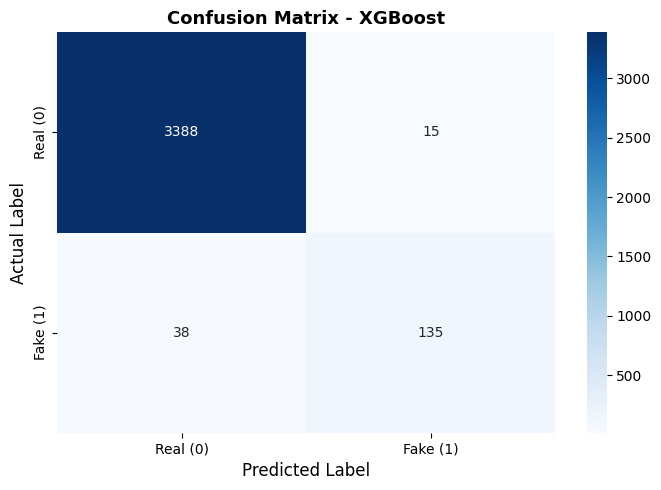


DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Real Job       0.99      1.00      0.99      3403
    Fake Job       0.90      0.78      0.84       173

    accuracy                           0.99      3576
   macro avg       0.94      0.89      0.91      3576
weighted avg       0.98      0.99      0.98      3576



In [64]:
# Confusion matrix shows:
# True Positive (TP): Fake job → predicted Fake ✓
# True Negative (TN): Real job → predicted Real ✓
# False Positive (FP): Real job → predicted Fake ✗ (false alarm)
# False Negative (FN): Fake job → predicted Real ✗ (missed fraud!)

cm = confusion_matrix(y_test, best_result['y_pred'])

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,           # show numbers in cells
    fmt='d',              # format as integer
    cmap='Blues',
    xticklabels=['Real (0)', 'Fake (1)'],
    yticklabels=['Real (0)', 'Fake (1)']
)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.title(f'Confusion Matrix - {best_result["name"]}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print classification report
print('\nDETAILED CLASSIFICATION REPORT:')
print(classification_report(y_test, best_result['y_pred'],
                             target_names=['Real Job', 'Fake Job']))

Save Model and All Files

In [65]:
os.makedirs('models', exist_ok=True)

In [66]:
joblib.dump(best_model, 'models/best_model.pkl')
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')

['models/tfidf_vectorizer.pkl']

In [67]:
summary = {
    'best_model_name': best_result['name'],
    'f1_score': round(best_result['f1'], 4),
    'recall': round(best_result['recall'], 4),
    'precision': round(best_result['precision'], 4),
    'roc_auc': round(best_result['roc_auc'], 4),
    'accuracy': round(best_result['accuracy'], 4)
}
import json
with open('models/model_info.json', 'w') as f:
    json.dump(summary, f, indent=2)

Test the Model

In [71]:
def predict_job(title, description, requirements='', benefits='',
                company_profile='', has_logo=0, telecommuting=0, has_questions=0):

    # Combine all text fields exactly like training
    combined = f'{title} {company_profile} {description} {requirements} {benefits}'

    # Clean text
    cleaned = clean_text(combined)

    # TF-IDF transform using same fitted vectorizer
    text_vector = tfidf.transform([cleaned])


    # X_extra = df[['text_length', 'word_count', 'has_logo', 'telecommute', 'has_questions']]
    text_length = len(cleaned)
    word_count  = len(cleaned.split())
    extra = csr_matrix([[text_length, word_count, int(has_logo), int(telecommuting), int(has_questions)]])

    # Combine TF-IDF + extra features
    X = hstack([text_vector, extra])

    # Get prediction and probability
    prediction = best_model.predict(X)[0]
    probability = best_model.predict_proba(X)[0][1]

    return prediction, probability


In [72]:
fake_title = 'Work from Home - Earn 50000 Monthly - No Experience Required'
fake_desc  = 'Immediate hiring! No skills needed. Guaranteed income. Send your details to join.'

# has_logo=0 because fake jobs rarely have logos
pred, prob = predict_job(fake_title, fake_desc, has_logo=0, has_questions=0)
print("--- Test 1: Suspicious Fake Job ---")
print(f"Title: {fake_title}")
print(f"Prediction : {'FAKE' if pred == 1 else 'REAL'}")
print(f"Probability: {prob:.1%}")
print()
# Expected: FAKE with high probability


--- Test 1: Suspicious Fake Job ---
Title: Work from Home - Earn 50000 Monthly - No Experience Required
Prediction : FAKE
Probability: 85.3%



In [70]:
real_title = 'Senior Software Engineer - Python and Django'
real_desc  = """We are looking for an experienced Python developer to join our engineering team.
Requirements: 5+ years Python, Django, REST APIs, PostgreSQL experience.
Salary: Competitive based on experience. Location: Bangalore.
Benefits: Health insurance, stock options, 25 days leave.
Apply through our careers portal with your resume and portfolio."""

real_company = "We are a product-based tech company founded in 2015 with 500+ employees across India and US."

# has_logo=1 and has_questions=1 because this is a real company posting
pred2, prob2 = predict_job(real_title, real_desc,
                            company_profile=real_company,
                            has_logo=1, has_questions=1)
print("--- Test 2: Legitimate Job ---")
print(f"Title: {real_title}")
print(f"Prediction : {'FAKE' if pred2 == 1 else 'REAL'}")
print(f"Probability: {prob2:.1%}")
print()
# Expected: REAL with low fraud probability


--- Test 2: Legitimate Job ---
Title: Senior Software Engineer - Python and Django
Prediction : REAL
Probability: 0.0%

